# Probe Analysis

Minimal notebook for probing batches of points and analyzing the returned arrays directly.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(root))

from client.config import registry
from client.interface import SlopClient

print(registry.list())


[ProviderConfig(name='vast-32582479', kind='ssh', target='vast-32582479', remote_path='/root/slop', python_cmd='python3', container_image=None, num_workers=8)]


In [2]:
providers = registry.list()
assert providers, 'no providers registered'
cfg = providers[-1]
client = SlopClient(cfg)
client.connect()

[REMOTE STDERR] Welcome to vast.ai. If authentication fails, try again after a few seconds, and double check your ssh key.
[REMOTE STDERR] Have fun!
[REMOTE STDERR] [SERVER] 2026-03-09 14:10:58,704 - INFO - server ready


In [5]:
points = np.random.randn(4, 4, 64, 64).astype(np.float32)
delta = client.probe_delta(points, prompt_a='a person', prompt_b='a warrior', timestep=5)
delta.shape

[REMOTE STDERR] [SERVER] 2026-03-09 14:12:49,948 - INFO - sample/probe request model=runwayml/stable-diffusion-v1-5


(4, 4, 64, 64)

In [6]:
flat = delta.reshape(delta.shape[0], -1)
norms = np.linalg.norm(flat, axis=1)
angles = flat @ flat.mean(axis=0)
norms[:5], angles[:5]

(array([9.55, 9.66, 9.4 , 9.87], dtype=float16),
 array([23.31, 24.1 , 22.7 , 25.12], dtype=float16))

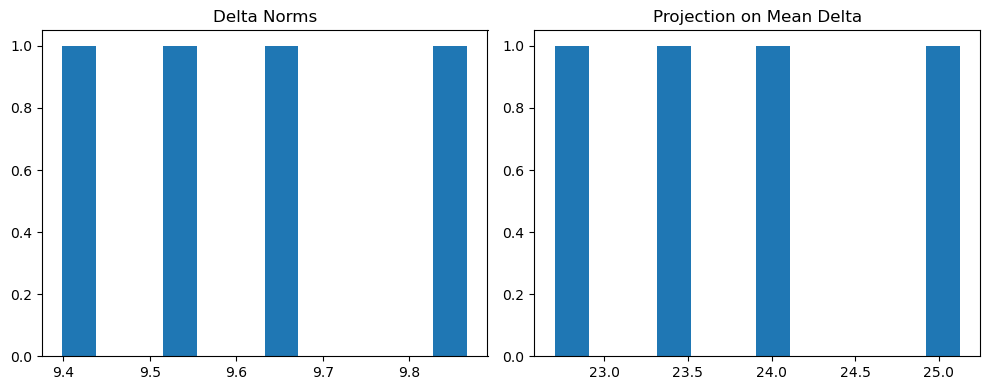

[REMOTE STDERR] Timeout, server ssh5.vast.ai not responding.


In [7]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(norms, bins=12)
plt.title('Delta Norms')
plt.subplot(1, 2, 2)
plt.hist(angles, bins=12)
plt.title('Projection on Mean Delta')
plt.tight_layout()
plt.show()

In [ ]:
client.close()